In [1]:
from data_tools import DBClient

client = DBClient(timeout=30)

In [2]:
bucket = "CAN_log"
measurements = client.get_measurements_in_bucket(bucket)
measurements

['TEL',
 'MEMORATOR',
 'OBC',
 'ECU',
 'MPPT',
 'STR',
 'MC',
 'MDI',
 'BMS',
 'MCB',
 'AMB',
 'DRD']

In [3]:
fields = set()
for measurement in measurements:
    new_fields = client.get_fields_in_measurement(bucket, measurement)
    print(new_fields)
    for field in new_fields:
        fields.add(field)

['GPSSecond', 'GPSMonth', 'Acceleration_X', 'GPSHour', 'Gyroscope_Y', 'GPSLongitude', 'GPSAltitude', 'IMUWriteFail', 'GPSSatInView', 'GPSVdop', 'GPSPdop', 'Gyroscope_X', 'IMUReadFail', 'Acceleration_Y', 'GPSSNR', 'GPSLatitude', 'GPSMagneticHeading', 'GPSLonSide', 'GPSSatCount', 'GPSDay', 'Acceleration_Z', 'GPSReadFail', 'GPSMinute', 'GPSSpeedkmh', 'GPSGeodHeight', 'TELTimeSinceBootUp', 'TELWatchdogReset', 'GPSHdop', 'Gyroscope_Z', 'GPSLatSide', 'GPSFix', 'GPSYear', 'GPSTrueHeading']
['Year', 'Hour', 'Second', 'Minute', 'Day', 'Month']
['CPSignalStatus', 'OutputOverCurrent', 'OutputCurrent', 'CCsignalStatus', 'Temperaturre', 'CommunicationStatus', 'CoolingPumpFanEnable', 'OutputShortCircuit', 'FanEnable', 'InputVoltageStatus', 'TemepratureProtection', 'HardwareProtection', 'CompletionOfInitialization', 'ChargingSocketTempFault', 'OutputVoltage', 'OutputUnderVoltage', 'WorkingStatus', 'OutputOverVoltage', 'S2SwitchControlStatus', 'ElectronicLockState']
['COC', 'LVCurrent', 'MaxChargingVo

In [131]:
from __future__ import annotations

from dataclasses import dataclass
from datetime import datetime, date, timedelta, timezone
from typing import Iterable, Optional, Dict, List
from data_tools.query import FluxQuery, FluxStatement


DAY = timedelta(days=1)

def query_series(client, start: datetime, stop: datetime, field: str, bucket: str = "CAN_log",
                 car: str = "Brightside", measurement: str = None):
    """
    Query the database for a specific field, over a certain time range.
    The data will be returned as a DataFrame.

    :param start: the start time of the query as an ISO 8601-compliant string, such as "2024-06-30T23:00:00Z".
    :param stop: the end time of the query as an ISO 8601-compliant string, such as "2024-06-30T23:00:00Z".
    :param field: the field which is to be queried.
    :param str bucket: the bucket which will be queried
    :param car: the car which data is being queried for, default is "Brightside".
    :return: a TimeSeries of the resulting time-series data
    """
    utc_start = start.astimezone(timezone.utc)
    utc_end = stop.astimezone(timezone.utc)

    # Make the query
    query = FluxQuery() \
        .from_bucket(bucket) \
        .range(start=utc_start.isoformat(), stop=utc_end.isoformat()) \
        .filter(field=field) \
        .car(car) \
        .inject_raw(FluxStatement("limit(n:1)", priority=10))

    if measurement:
        query = query.filter(measurement=measurement)
    return client.query_dataframe(query)

@dataclass(frozen=True)
class FieldCoverage:
    earliest_day: Optional[date]
    latest_day: Optional[date]

def floor_day(dt: datetime, tz: timezone | None = None) -> datetime:
    if tz is not None:
        dt = dt.astimezone(tz) if dt.tzinfo else dt.replace(tzinfo=tz)
    return dt.replace(hour=0, minute=0, second=0, microsecond=0)

def query_active_days(client, start: datetime, stop: datetime) -> Iterable[date]:
    query_str = f"""
    from(bucket: "CAN_log") |> range(start: {start.isoformat()}Z, stop: {stop.isoformat()}Z) |> filter(fn: (r) => r.car == "Brightside") |> aggregateWindow(every: 1h, fn: count, createEmpty: false) |> keep(columns: ["_time", "_value"]) |> filter(fn: (r) => r._value > 0)
    """

    df = client._client.query_api().query_data_frame(query_str)
    all_times = set(df["_time"].tolist())

    return list([x.date() for x in all_times])


def find_coverage_sparse_days(
    client,
    fields: Iterable[str],
    global_start: datetime,
    global_stop: datetime,
    tz: timezone | None = None,
) -> tuple[Dict[str, FieldCoverage], list]:
    gs = floor_day(global_start, tz)
    ge = floor_day(global_stop, tz)
    if ge <= gs:
        return {f: FieldCoverage(None, None) for f in fields}

    # 1) Discover days with *any* data (for the relevant scope, e.g. car/bucket)
    active_days: List[date] = sorted(set(query_active_days(client, gs, ge)))
    if not active_days:
        return {f: FieldCoverage(None, None) for f in fields}

    # 2) For each field, probe only those days
    out: Dict[str, FieldCoverage] = {}
    for field in fields:
        present: List[date] = []
        for d in active_days:
            start = datetime(d.year, d.month, d.day, tzinfo=gs.tzinfo)
            stop = start + DAY
            try:
                query = query_series(client, start=start, stop=stop, field=field)
                if len(query) > 0:
                    present.append(d)
            except Exception:
                pass

        if not present:
            out[field] = FieldCoverage(None, None)
        else:
            out[field] = FieldCoverage(min(present), max(present))
    return out, active_days

In [134]:
out, active_days = find_coverage_sparse_days(client, fields, datetime(2024, 1, 1), datetime(2026, 2, 28))

/Users/joshuariefman/Solar/data_tools/.venv/lib/python3.13/site-packages/influxdb_client/client/warnings.py:31: MissingPivotFunction: The query doesn't contains the pivot() function.

The result will not be shaped to optimal processing by pandas.DataFrame. Use the pivot() function by:

    
    from(bucket: "CAN_log") |> range(start: 2024-01-01T00:00:00Z, stop: 2026-02-28T00:00:00Z) |> filter(fn: (r) => r.car == "Brightside") |> aggregateWindow(every: 1h, fn: count, createEmpty: false) |> keep(columns: ["_time", "_value"]) |> filter(fn: (r) => r._value > 0)
     |> pivot(rowKey:["_time"], columnKey: ["_field"], valueColumn: "_value")

You can disable this warning by:
    import warnings
    from influxdb_client.client.warnings import MissingPivotFunction

    warnings.simplefilter("ignore", MissingPivotFunction)

For more info see:
    - https://docs.influxdata.com/resources/videos/pivots-in-flux/
    - https://docs.influxdata.com/flux/latest/stdlib/universe/pivot/
    - https://docs.i

In [147]:
active_days

[datetime.date(2024, 7, 12),
 datetime.date(2024, 7, 13),
 datetime.date(2024, 7, 14),
 datetime.date(2024, 7, 15),
 datetime.date(2024, 7, 16),
 datetime.date(2024, 7, 17),
 datetime.date(2024, 7, 18),
 datetime.date(2024, 7, 20),
 datetime.date(2025, 4, 1),
 datetime.date(2025, 4, 5),
 datetime.date(2025, 4, 6),
 datetime.date(2025, 4, 12),
 datetime.date(2025, 4, 13),
 datetime.date(2025, 5, 18),
 datetime.date(2025, 5, 24),
 datetime.date(2025, 5, 30),
 datetime.date(2025, 5, 31),
 datetime.date(2025, 6, 7),
 datetime.date(2025, 6, 8),
 datetime.date(2025, 6, 16),
 datetime.date(2025, 6, 17),
 datetime.date(2025, 6, 18),
 datetime.date(2025, 6, 19),
 datetime.date(2025, 6, 22),
 datetime.date(2025, 6, 23),
 datetime.date(2025, 6, 30),
 datetime.date(2025, 7, 1),
 datetime.date(2025, 7, 2),
 datetime.date(2025, 7, 3),
 datetime.date(2025, 7, 4),
 datetime.date(2025, 7, 5),
 datetime.date(2025, 7, 23),
 datetime.date(2026, 1, 20),
 datetime.date(2026, 1, 24)]

In [135]:
out

{'Module23': FieldCoverage(earliest_day=datetime.date(2024, 7, 12), latest_day=datetime.date(2026, 1, 24)),
 'AcceleratorPosition': FieldCoverage(earliest_day=datetime.date(2024, 7, 13), latest_day=datetime.date(2026, 1, 24)),
 'Mod13_BalActive': FieldCoverage(earliest_day=datetime.date(2024, 7, 12), latest_day=datetime.date(2026, 1, 24)),
 'Reserved2': FieldCoverage(earliest_day=datetime.date(2024, 7, 13), latest_day=datetime.date(2024, 7, 20)),
 'MCBDriveCmdTimeout': FieldCoverage(earliest_day=datetime.date(2024, 7, 14), latest_day=datetime.date(2024, 7, 14)),
 'ControllerVoltageSensorError': FieldCoverage(earliest_day=datetime.date(2024, 7, 13), latest_day=datetime.date(2026, 1, 24)),
 'MPPTPCACTIVE': FieldCoverage(earliest_day=datetime.date(2025, 5, 30), latest_day=datetime.date(2026, 1, 24)),
 'Voltage19': FieldCoverage(earliest_day=datetime.date(2024, 7, 12), latest_day=datetime.date(2026, 1, 24)),
 'CurrentSensor2': FieldCoverage(earliest_day=datetime.date(2024, 7, 12), latest_d

In [145]:
from __future__ import annotations
from datetime import date
import numpy as np
from matplotlib import dates as mdates
from matplotlib import pyplot as plt

def plot_field_coverages(coverages: dict[str, tuple[date|None, date|None]], title="Field Coverage by Day"):
    """
    coverages: dict[field] = (earliest_day, latest_day) where values are date or None
    """

    rows = []
    for field, (e, l) in coverages.items():
        if e is None or l is None:
            continue
        rows.append((field, e, l))

    # Sort by earliest day, then latest
    rows.sort(key=lambda x: (x[1], x[2]))

    if not rows:
        print("No coverages to plot.")
        return

    # Prepare data
    y = list(range(len(rows)))
    x0 = [mdates.date2num(e) for _, e, _ in rows]
    x1 = [mdates.date2num(l) for _, _, l in rows]

    ranges = [[x, y] for x, y in zip(x0, x1) if not x == y]
    ranges = np.array(ranges)

    print("Signals with only one day:")
    for i, (x0i, x1i) in enumerate(zip(x0, x1)):
        if x0i == x1i:
            print(rows[i][0])

    fig, ax = plt.subplots()
    ax.hlines(y=np.array(range(ranges.shape[0])), xmin=ranges[:, 0], xmax=ranges[:, 1], linewidth=0.66, color="white")

    ax.set_title(f"{title} (n={ranges.shape[0]} fields)")
    ax.set_xlabel("Date")
    ax.set_ylabel("Fields (sorted by earliest day)")

    # Make dates readable
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))

    # Too many to label cleanly → hide y ticks
    ax.set_yticks([])

    ax.grid(True, axis="x", alpha=0.3)
    fig.tight_layout()
    plt.show()

Signals with only one day:
MCBDriveCmdTimeout
RegenSentToMC
DriveModeToMC
DirectionSentToMC


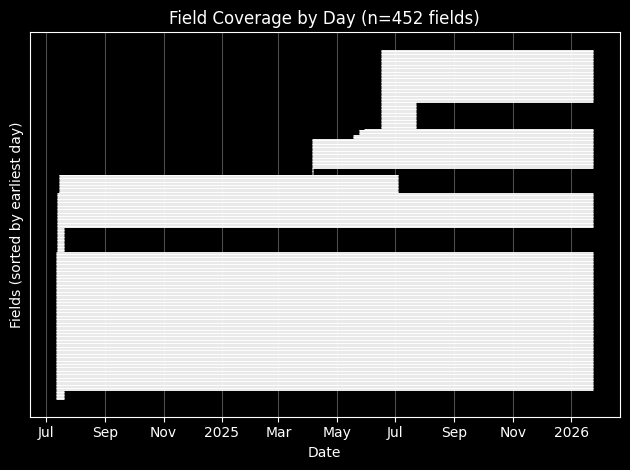

In [146]:
plot_field_coverages({f: (cov.earliest_day, cov.latest_day) for f, cov in out.items()})

In [139]:
from datetime import date
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

def plot_earliest_vs_latest(coverages: dict[str, tuple[date|None, date|None]], title="Earliest vs latest day"):
    pts = []
    for _, (e, l) in coverages.items():
        if e is None or l is None:
            continue
        pts.append((e, l))
    if not pts:
        print("No coverages to plot.")
        return

    xs = [mdates.date2num(e) for e, _ in pts]
    ys = [mdates.date2num(l) for _, l in pts]

    fig, ax = plt.subplots()
    ax.scatter(xs, ys, s=10)  # size small for 456 points

    # diagonal y=x
    mn = min(min(xs), min(ys))
    mx = max(max(xs), max(ys))
    ax.plot([mn, mx], [mn, mx], linewidth=1)

    ax.set_title(f"{title} (n={len(pts)} fields)")
    ax.set_xlabel("Earliest day")
    ax.set_ylabel("Latest day")

    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.yaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
    ax.yaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.yaxis.get_major_locator()))

    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    plt.show()

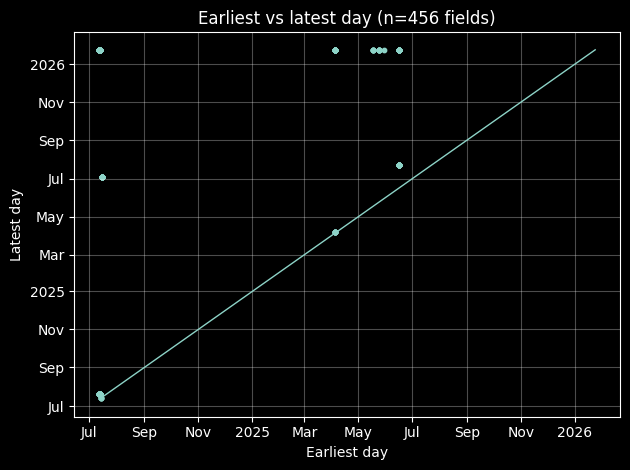

In [140]:
plot_earliest_vs_latest({f: (cov.earliest_day, cov.latest_day) for f, cov in out.items()})

In [141]:
from datetime import date
import matplotlib.pyplot as plt

def plot_duration_hist(coverages: dict[str, tuple[date|None, date|None]], title="Coverage duration (days)"):
    durations = []
    for _, (e, l) in coverages.items():
        if e is None or l is None:
            continue
        durations.append((l - e).days + 1)

    if not durations:
        print("No coverages to plot.")
        return

    fig, ax = plt.subplots()
    ax.hist(durations, bins=30)

    ax.set_title(f"{title} (n={len(durations)} fields)")
    ax.set_xlabel("Days covered (latest - earliest + 1)")
    ax.set_ylabel("Count of fields")
    ax.grid(True, alpha=0.3)

    fig.tight_layout()
    plt.show()

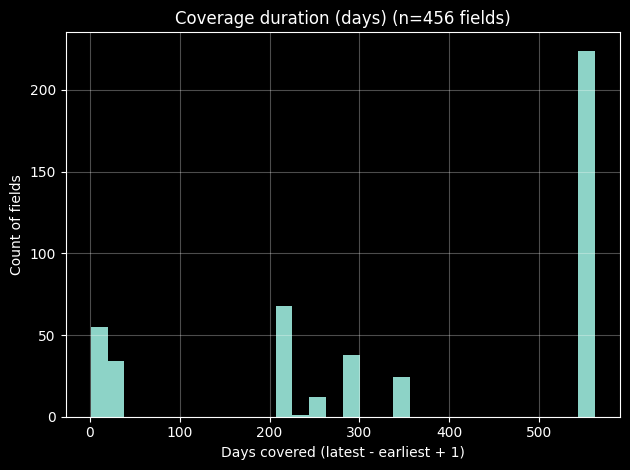

In [142]:
plot_duration_hist({f: (cov.earliest_day, cov.latest_day) for f, cov in out.items()})
